<a href="https://colab.research.google.com/github/solehas25h-salmasoleha/Co-Kriging/blob/main/Co_Kriging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Silakan pilih dan upload file 'meuse.txt' dari perangkat Anda:


Saving meuse.txt to meuse (15).txt

[INFO] Total data valid dimuat: 155 baris observasi.

 1. ANALISIS STATISTIK DESKRIPTIF VARIABEL UTAMA & SEKUNDER
         Count        Mean         Std    Min  Median     Max
zinc     155.0  469.716129  367.073788  113.0   326.0  1839.0
copper   155.0   40.316129   23.680436   14.0    31.0   128.0
lead     155.0  153.361290  111.320054   37.0   123.0   654.0
cadmium  155.0    3.245806    3.523746    0.2     2.1    18.1

[INFO] Menghasilkan Visualisasi EDA & Matriks Korelasi...


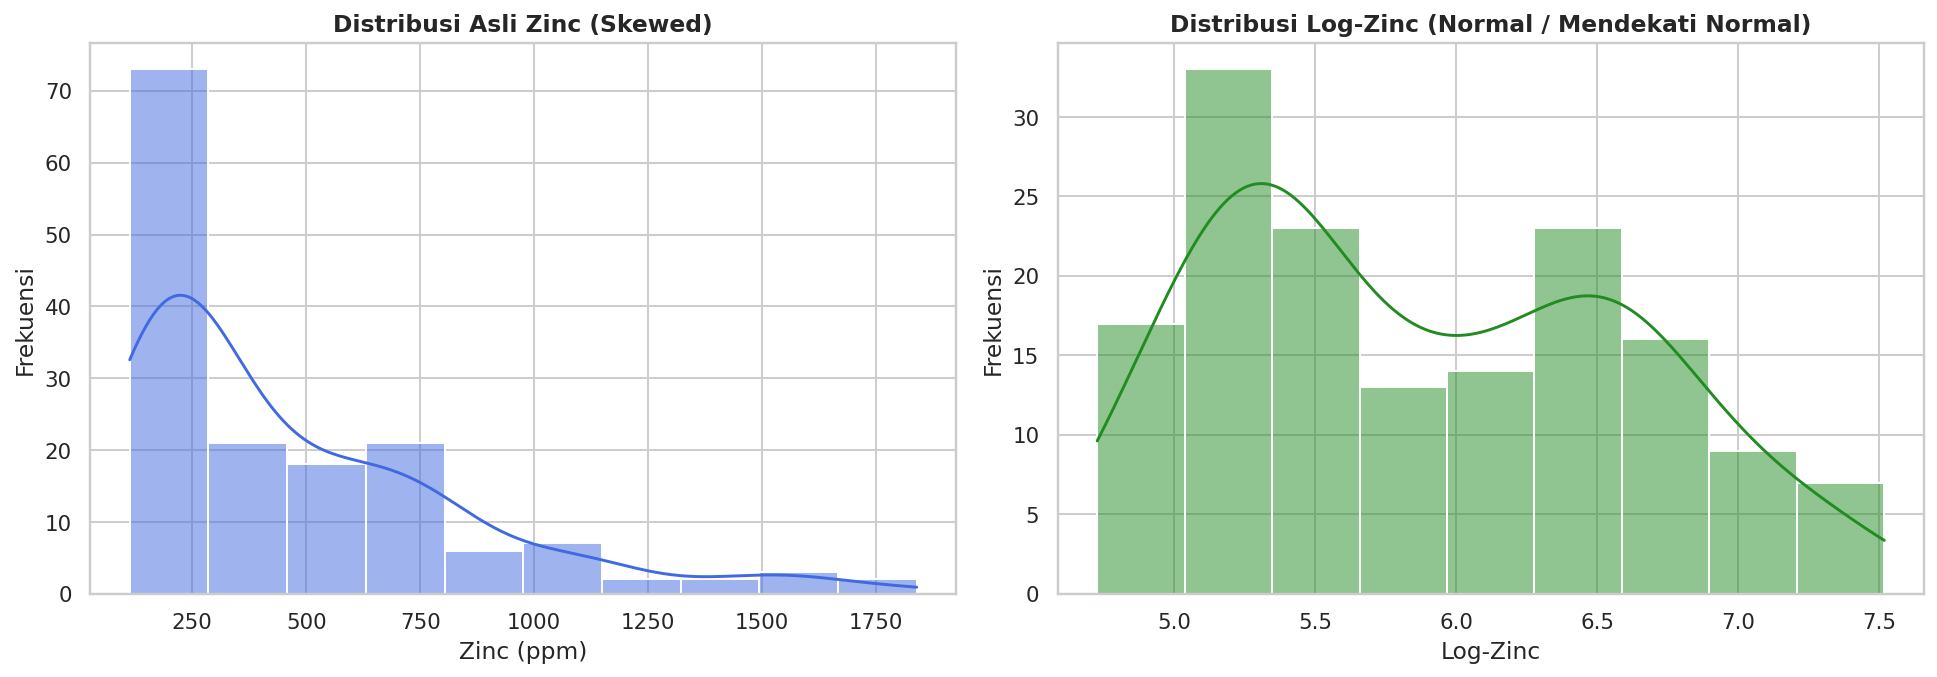

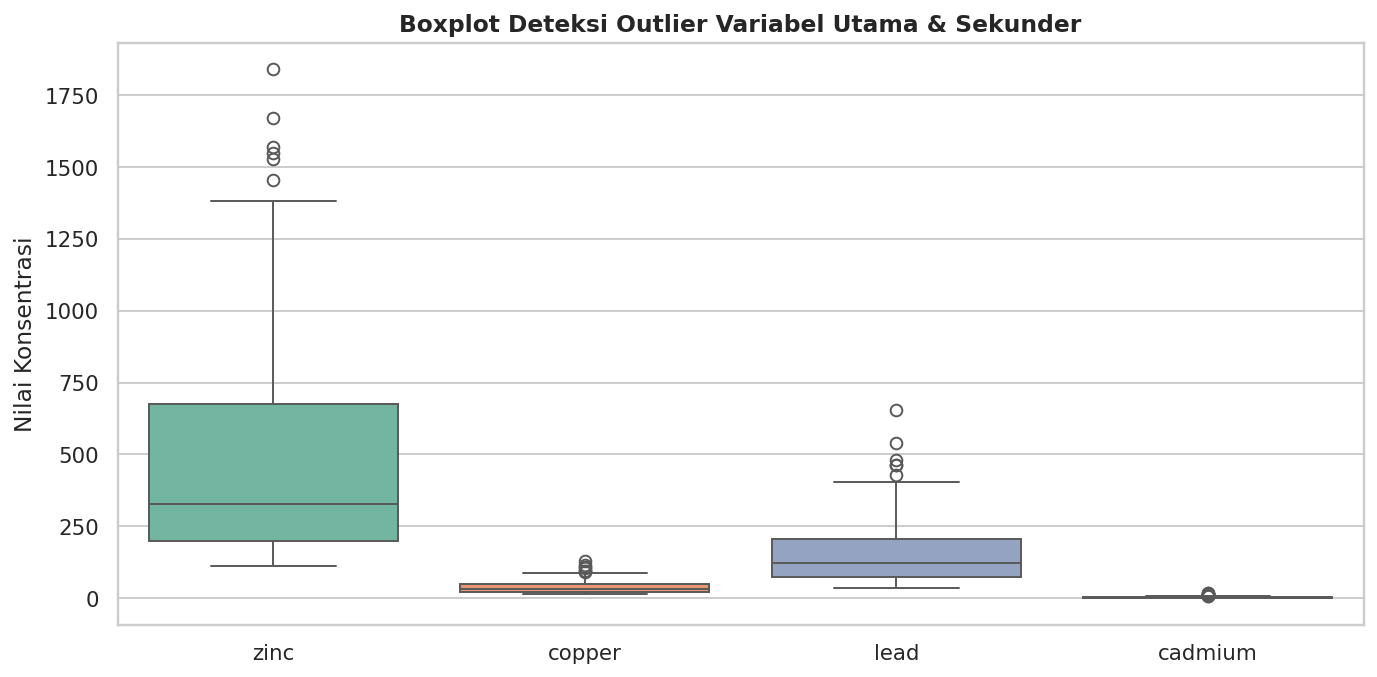

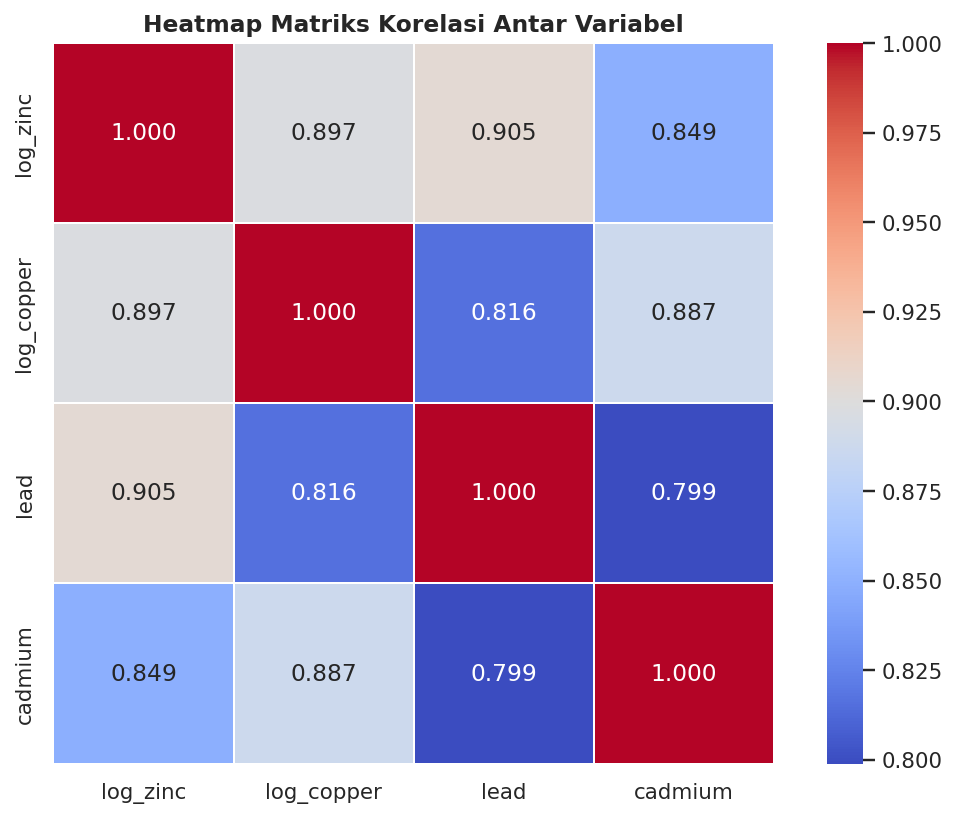

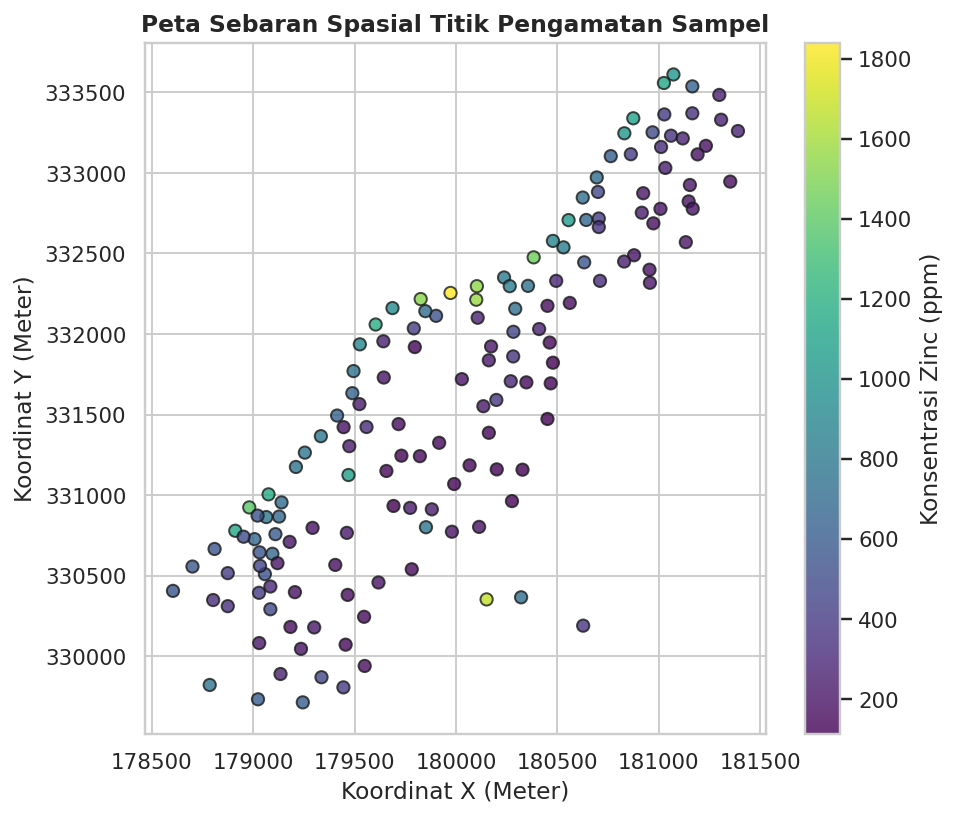


 TABEL 3.1: PERBANDINGAN PARAMETER & SSE MODEL VARIOGRAM
Model Variogram  Nugget (c0)  Sill (c0+c)  Range (a)  Nilai SSE
    Exponential     0.000000     0.683398 392.473676   0.016729
      Spherical     0.024109     0.640137 875.106615   0.006249
       Gaussian     0.097508     0.639903 418.483770   0.007941

[INFO] Model variogram terbaik berdasarkan SSE terkecil: Spherical


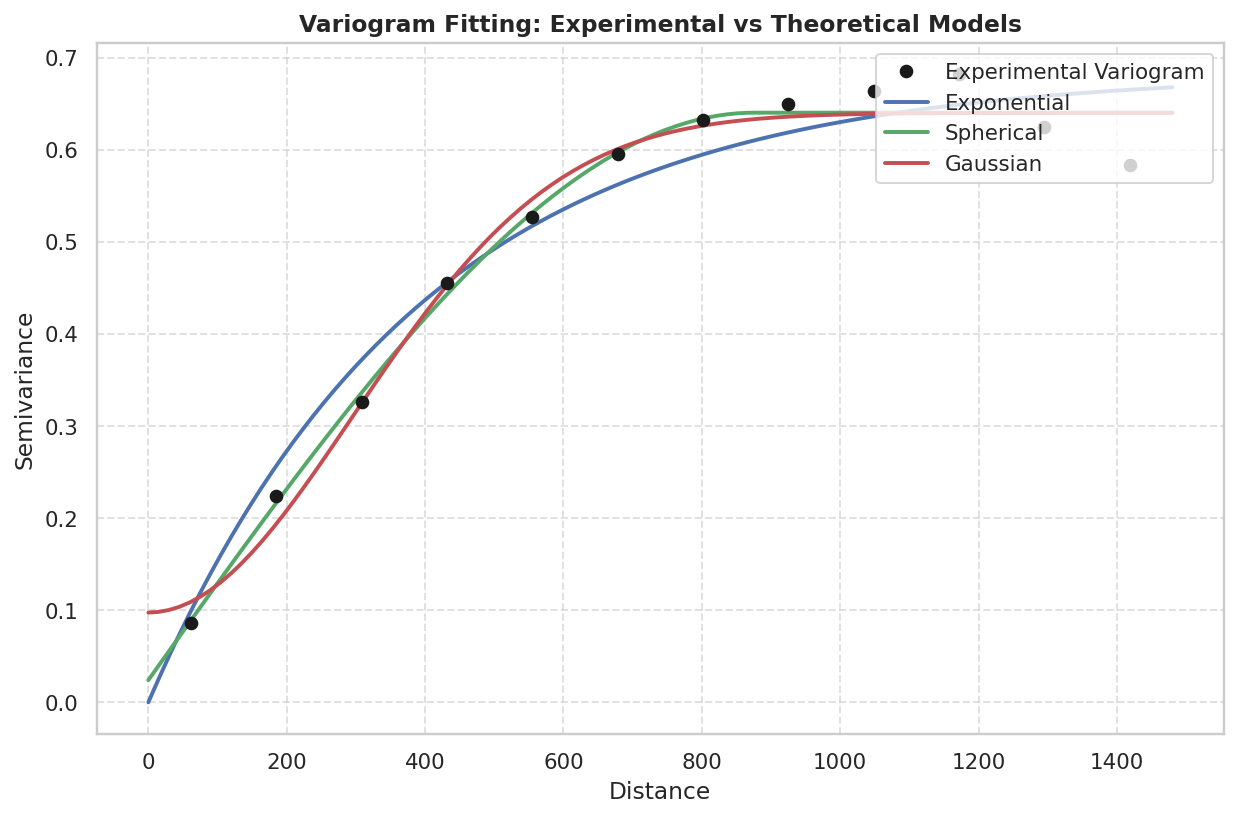


[INFO] Menjalankan Leave-One-Out Cross-Validation (LOOCV) Kriging...

 HASIL EVALUASI VALIDASI SILANG ORDINARY KRIGING
 RMSE (Skala Log) : 0.3871
 MAE (Skala Log)  : 0.2863
 Koefisien (R²)   : 0.7106


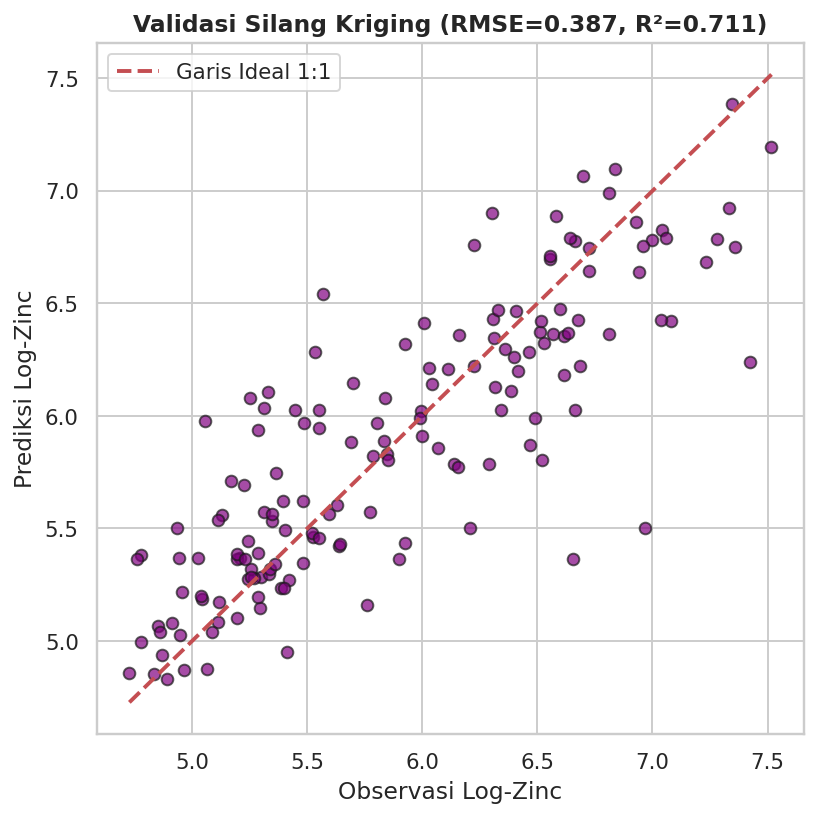

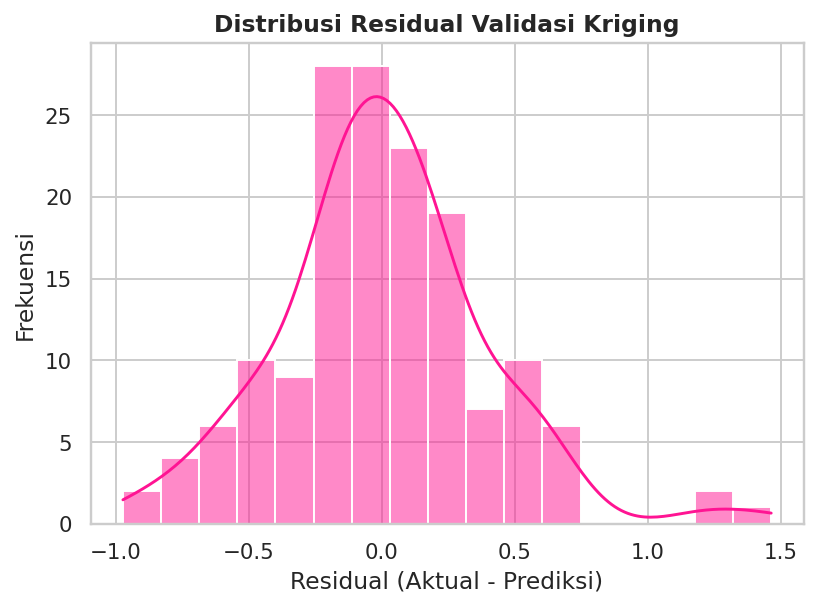


[INFO] Membangun Grid Peta Interpolasi dan Ragam Kriging...


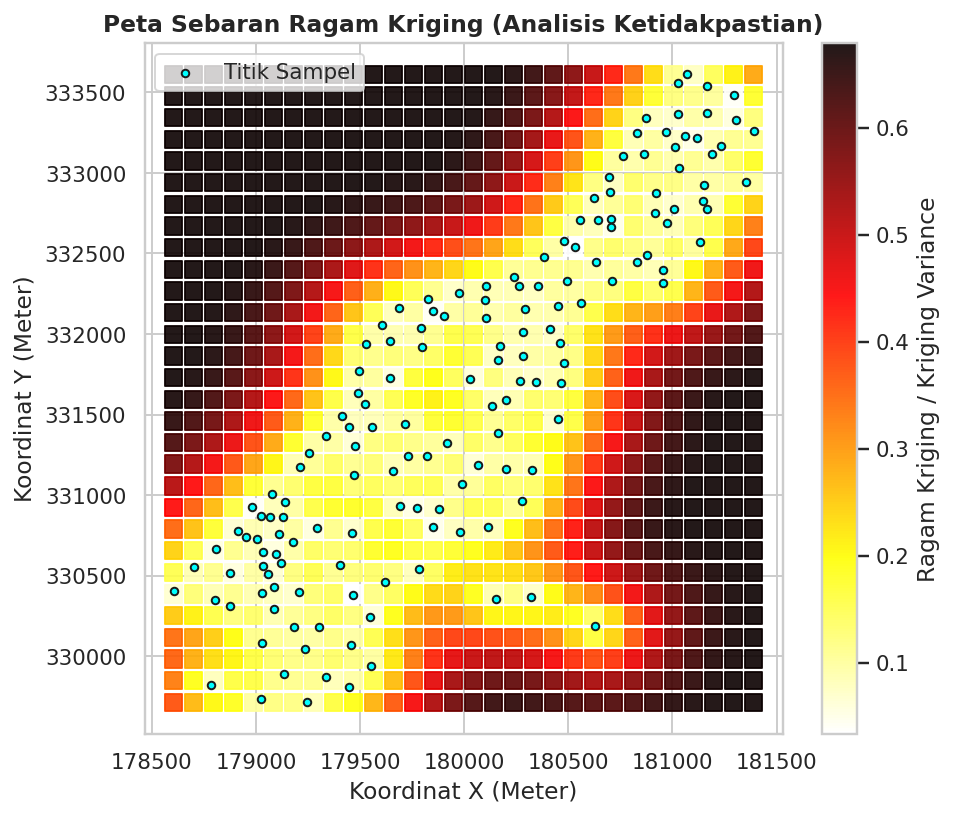

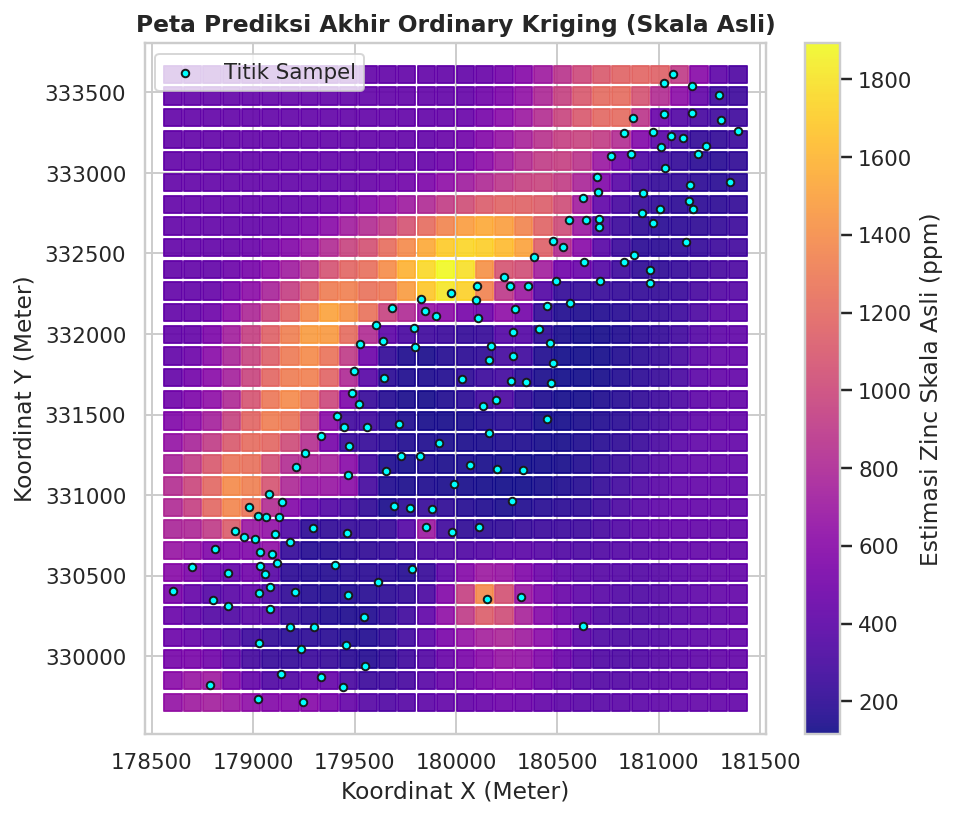

In [18]:
# ==============================================================================
# MASTER SCRIPT PYTHON FULL: EDA, KORELASI, FITTING VARIOGRAM, CO-KRIGING, & PETA
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import minimize
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Pengaturan Tema Visualisasi Akademik
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 140

# ==============================================================================
# TAHAP 1: UPLOAD DATA & STATISTIK DESKRIPTIF
# ==============================================================================
print("Silakan pilih dan upload file 'meuse.txt' dari perangkat Anda:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df_meuse = pd.read_csv(filename).dropna(subset=['zinc', 'copper', 'lead', 'cadmium'])

print(f"\n[INFO] Total data valid dimuat: {len(df_meuse)} baris observasi.")

print("\n" + "="*70)
print(" 1. ANALISIS STATISTIK DESKRIPTIF VARIABEL UTAMA & SEKUNDER")
print("="*70)
desc_table = df_meuse[['zinc', 'copper', 'lead', 'cadmium']].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]
desc_table.columns = ['Count', 'Mean', 'Std', 'Min', 'Median', 'Max']
print(desc_table.to_string())
print("="*70)


# ==============================================================================
# TAHAP 2: VISUALISASI EDA KOMPREHENSIF & MATRIKS KORELASI
# ==============================================================================
print("\n[INFO] Menghasilkan Visualisasi EDA & Matriks Korelasi...")

# A. Transformasi Log-Natural
df_meuse['log_zinc'] = np.log(df_meuse['zinc'])
df_meuse['log_copper'] = np.log(df_meuse['copper'])

# B. Histogram & KDE (Sebelum vs Sesudah Transformasi)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_meuse['zinc'], kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Distribusi Asli Zinc (Skewed)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Zinc (ppm)')
axes[0].set_ylabel('Frekuensi')

sns.histplot(df_meuse['log_zinc'], kde=True, ax=axes[1], color='forestgreen')
axes[1].set_title('Distribusi Log-Zinc (Normal / Mendekati Normal)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Log-Zinc')
axes[1].set_ylabel('Frekuensi')
plt.tight_layout()
plt.show()

# C. Boxplot Outlier
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_meuse[['zinc', 'copper', 'lead', 'cadmium']], palette='Set2')
plt.title('Boxplot Deteksi Outlier Variabel Utama & Sekunder', fontsize=12, fontweight='bold')
plt.ylabel('Nilai Konsentrasi')
plt.tight_layout()
plt.show()

# D. Heatmap Matriks Korelasi
plt.figure(figsize=(8, 6))
corr_vars = ['log_zinc', 'log_copper', 'lead', 'cadmium']
corr_matrix = df_meuse[corr_vars].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=1, cbar=True, square=True)
plt.title('Heatmap Matriks Korelasi Antar Variabel', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# E. Peta Sebaran Spasial Titik Sampel
plt.figure(figsize=(7, 6))
scatter = plt.scatter(df_meuse['x'], df_meuse['y'], c=df_meuse['zinc'], cmap='viridis', s=40, edgecolors='k', alpha=0.8)
plt.colorbar(scatter, label='Konsentrasi Zinc (ppm)')
plt.title('Peta Sebaran Spasial Titik Pengamatan Sampel', fontsize=12, fontweight='bold')
plt.xlabel('Koordinat X (Meter)')
plt.ylabel('Koordinat Y (Meter)')
plt.tight_layout()
plt.show()


# ==============================================================================
# TAHAP 3: PERHITUNGAN VARIOGRAM EMPIRIS & FITTING MODEL TEORETIS
# ==============================================================================
coords = df_meuse[['x', 'y']].values
z1_log = df_meuse['log_zinc'].values
z2_log = df_meuse['log_copper'].values

def compute_variogram(coords, z, n_lags=12, max_dist=None):
    dist_matrix = squareform(pdist(coords))
    if max_dist is None: max_dist = np.max(dist_matrix) / 3.0
    dz = z[:, None] - z[None, :]
    gamma_mat = 0.5 * (dz**2)
    bins = np.linspace(0, max_dist, n_lags + 1)
    lags = 0.5 * (bins[:-1] + bins[1:])
    gamma_emp = []
    for i in range(n_lags):
        mask = (dist_matrix >= bins[i]) & (dist_matrix < bins[i+1])
        if np.sum(mask) > 0: gamma_emp.append(np.mean(gamma_mat[mask]))
        else: gamma_emp.append(np.nan)
    return lags, np.array(gamma_emp)

max_d = np.max(pdist(coords)) / 3.0
lags, gamma_emp = compute_variogram(coords, z1_log, max_dist=max_d)

def theoretical_model(h, c0, c, a, m_type):
    h = np.asarray(h)
    if m_type == 'spherical':
        return c0 + c * np.where(h <= a, 1.5 * (h / a) - 0.5 * (h / a)**3, 1.0)
    elif m_type == 'exponential':
        return c0 + c * (1.0 - np.exp(-h / a))
    elif m_type == 'gaussian':
        return c0 + c * (1.0 - np.exp(-(h**2) / (a**2)))

def fit_model(m_type):
    def loss(params):
        c0, c, a = params
        if c0 < 0 or c < 0 or a <= 0: return 1e9
        pred = theoretical_model(lags, c0, c, a, m_type)
        valid = ~np.isnan(gamma_emp)
        return np.sum((gamma_emp[valid] - pred[valid])**2)
    res = minimize(loss, [0.05, 0.5, max_d/2], bounds=[(0,None),(0,None),(10,max_d)], method='L-BFGS-B')
    return res.x, res.fun

p_exp, sse_exp = fit_model('exponential')
p_sph, sse_sph = fit_model('spherical')
p_gau, sse_gau = fit_model('gaussian')

df_table_lacking = pd.DataFrame({
    'Model Variogram': ['Exponential', 'Spherical', 'Gaussian'],
    'Nugget (c0)': [p_exp[0], p_sph[0], p_gau[0]],
    'Sill (c0+c)': [p_exp[0]+p_exp[1], p_sph[0]+p_sph[1], p_gau[0]+p_gau[1]],
    'Range (a)': [p_exp[2], p_sph[2], p_gau[2]],
    'Nilai SSE': [sse_exp, sse_sph, sse_gau]
})

print("\n" + "="*85)
print(" TABEL 3.1: PERBANDINGAN PARAMETER & SSE MODEL VARIOGRAM")
print("="*85)
print(df_table_lacking.to_string(index=False))
print("="*85)

best_idx = df_table_lacking['Nilai SSE'].idxmin()
best_model_name = df_table_lacking.loc[best_idx, 'Model Variogram']
print(f"\n[INFO] Model variogram terbaik berdasarkan SSE terkecil: {best_model_name}")

if best_model_name == 'Exponential': c0_s, c_s, range_s, m_type_sel = p_exp[0], p_exp[1], p_exp[2], 'exponential'
elif best_model_name == 'Spherical': c0_s, c_s, range_s, m_type_sel = p_sph[0], p_sph[1], p_sph[2], 'spherical'
else: c0_s, c_s, range_s, m_type_sel = p_gau[0], p_gau[1], p_gau[2], 'gaussian'

# Plot Fitting Perbandingan 3 Model
plt.figure(figsize=(9, 6))
plt.plot(lags, gamma_emp, 'ko', label='Experimental Variogram', zorder=5)
h_grid = np.linspace(0, max_d, 100)
plt.plot(h_grid, theoretical_model(h_grid, p_exp[0], p_exp[1], p_exp[2], 'exponential'), 'b-', lw=2, label='Exponential')
plt.plot(h_grid, theoretical_model(h_grid, p_sph[0], p_sph[1], p_sph[2], 'spherical'), 'g-', lw=2, label='Spherical')
plt.plot(h_grid, theoretical_model(h_grid, p_gau[0], p_gau[1], p_gau[2], 'gaussian'), 'r-', lw=2, label='Gaussian')
plt.title('Variogram Fitting: Experimental vs Theoretical Models', fontsize=12, fontweight='bold')
plt.xlabel('Distance')
plt.ylabel('Semivariance')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# ==============================================================================
# TAHAP 4: ORDINARY KRIGING, VALIDASI SILANG (LOOCV), & PEMETAAN SPASIAL
# ==============================================================================
def get_cov(h, c0, c, a, m_type):
    sill = c0 + c
    return sill - theoretical_model(h, c0, c, a, m_type)

def ok_predict_single(s_coords, z_s, target_coord):
    n = len(s_coords)
    D = squareform(pdist(s_coords))
    C = get_cov(D, c0_s, c_s, range_s, m_type_sel)

    K = np.zeros((n + 1, n + 1))
    K[:n, :n] = C
    K[:n, n] = 1.0
    K[n, :n] = 1.0

    dt = np.sqrt(np.sum((s_coords - target_coord)**2, axis=1))
    k0 = np.zeros(n + 1)
    k0[:n] = get_cov(dt, c0_s, c_s, range_s, m_type_sel)
    k0[n] = 1.0

    weights = np.linalg.solve(K + np.eye(n+1)*1e-5, k0)
    lam = weights[:n]
    mu = weights[n]

    log_pred = np.sum(lam * z_s)
    variance = (c0_s + c_s) - (np.sum(lam * k0[:n]) + mu)
    return np.exp(log_pred), log_pred, max(0, variance)

print("\n[INFO] Menjalankan Leave-One-Out Cross-Validation (LOOCV) Kriging...")
y_true_log = z1_log
y_pred_log, residuals = [], []

for i in range(len(coords)):
    mask = np.ones(len(coords), dtype=bool)
    mask[i] = False
    _, l_pred, _ = ok_predict_single(coords[mask], z1_log[mask], coords[i])
    y_pred_log.append(l_pred)
    residuals.append(y_true_log[i] - l_pred)

y_pred_log = np.array(y_pred_log)
residuals = np.array(residuals)

rmse = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
mae = mean_absolute_error(y_true_log, y_pred_log)
r2 = r2_score(y_true_log, y_pred_log)

print("\n" + "="*55)
print(" HASIL EVALUASI VALIDASI SILANG ORDINARY KRIGING")
print("="*55)
print(f" RMSE (Skala Log) : {rmse:.4f}")
print(f" MAE (Skala Log)  : {mae:.4f}")
print(f" Koefisien (R²)   : {r2:.4f}")
print("="*55)

# Plot Validasi Silang (Aktual vs Prediksi)
plt.figure(figsize=(6, 6))
plt.scatter(y_true_log, y_pred_log, color='purple', alpha=0.7, edgecolors='k')
plt.plot([y_true_log.min(), y_true_log.max()], [y_true_log.min(), y_true_log.max()], 'r--', lw=2, label='Garis Ideal 1:1')
plt.title(f'Validasi Silang Kriging (RMSE={rmse:.3f}, R²={r2:.3f})', fontsize=12, fontweight='bold')
plt.xlabel('Observasi Log-Zinc')
plt.ylabel('Prediksi Log-Zinc')
plt.legend()
plt.tight_layout()
plt.show()

# Plot Distribusi Residual
plt.figure(figsize=(6, 4.5))
sns.histplot(residuals, kde=True, color='deeppink')
plt.title('Distribusi Residual Validasi Kriging', fontsize=12, fontweight='bold')
plt.xlabel('Residual (Aktual - Prediksi)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

# Pembuatan Grid Peta Spasial & Kriging Variance
print("\n[INFO] Membangun Grid Peta Interpolasi dan Ragam Kriging...")
grid_x = np.linspace(df_meuse['x'].min(), df_meuse['x'].max(), 30)
grid_y = np.linspace(df_meuse['y'].min(), df_meuse['y'].max(), 30)
GX, GY = np.meshgrid(grid_x, grid_y)
G_coords = np.c_[GX.ravel(), GY.ravel()]

preds_original, krig_vars = [], []
for pt in G_coords:
    p_orig, _, var = ok_predict_single(coords, z1_log, pt)
    preds_original.append(p_orig)
    krig_vars.append(var)

preds_original = np.array(preds_original)
krig_vars = np.array(krig_vars)

# Peta Ketidakpastian (Kriging Variance)
plt.figure(figsize=(7, 6))
plt.scatter(G_coords[:, 0], G_coords[:, 1], c=krig_vars, cmap='hot_r', s=80, marker='s', alpha=0.9)
plt.colorbar(label='Ragam Kriging / Kriging Variance')
plt.scatter(df_meuse['x'], df_meuse['y'], c='cyan', s=15, edgecolors='k', label='Titik Sampel')
plt.title('Peta Sebaran Ragam Kriging (Analisis Ketidakpastian)', fontsize=12, fontweight='bold')
plt.xlabel('Koordinat X (Meter)')
plt.ylabel('Koordinat Y (Meter)')
plt.legend()
plt.tight_layout()
plt.show()

# Peta Prediksi Akhir (Skala Asli)
plt.figure(figsize=(7, 6))
plt.scatter(G_coords[:, 0], G_coords[:, 1], c=preds_original, cmap='plasma', s=80, marker='s', alpha=0.9)
plt.colorbar(label='Estimasi Zinc Skala Asli (ppm)')
plt.scatter(df_meuse['x'], df_meuse['y'], c='cyan', s=15, edgecolors='k', label='Titik Sampel')
plt.title('Peta Prediksi Akhir Ordinary Kriging (Skala Asli)', fontsize=12, fontweight='bold')
plt.xlabel('Koordinat X (Meter)')
plt.ylabel('Koordinat Y (Meter)')
plt.legend()
plt.tight_layout()
plt.show()